In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- 1. UPLOAD AND LOAD DATASET ---

In [14]:
# 1. UPLOAD AND LOAD DATASET
df = pd.read_csv('socialmedia_data.csv')
print('Dataset loaded successfully.')

Dataset loaded successfully.


# --- 2. DATA CLEANING ---

In [15]:
# 2. DATA CLEANING
print('\nMissing values:')
print(df.isnull().sum())
df = df.drop_duplicates(subset=['User_ID'])
print('\nDuplicates removed. Remaining rows:', len(df))
print('\nCleaning done. Final shape:', df.shape)


Missing values:
User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

Duplicates removed. Remaining rows: 50000

Cleaning done. Final shape: (50000, 13)


# --- 3. FEATURE ENGINEERING ---

In [16]:
# 3. FEATURE ENGINEERING
# Categorize Stress Level (High Stress if >= 7)
df['High Stress'] = df['Stress_Level'].apply(lambda x: 'Yes' if x >= 7 else 'No')
# Total Weekly Screen Time Estimate
df['Estimated Weekly Screen Time'] = (df['Daily_Phone_Hours'] * 5) + (df['Weekend_Screen_Time_Hours'] * 2)
print('\nNew columns added:')
print(df[['High Stress', 'Estimated Weekly Screen Time']].head())


New columns added:
  High Stress  Estimated Weekly Screen Time
0          No                          23.9
1          No                          16.2
2          No                          39.1
3          No                          54.6
4          No                          59.3


# --- 4. BASIC EDA - DATA SUMMARY ---

In [17]:
# 4. BASIC EDA - DATA SUMMARY
avg_phone = df['Daily_Phone_Hours'].mean()
avg_social = df['Social_Media_Hours'].mean()
avg_sleep = df['Sleep_Hours'].mean()
avg_productivity = df['Work_Productivity_Score'].mean()
print('\n--- SOCIAL MEDIA & SCREEN TIME SUMMARY ---')
print('Total Users Analyzed       :', len(df))
print('Average Daily Phone Hours  :', round(avg_phone, 2))
print('Average Social Media Hours :', round(avg_social, 2))
print('Average Sleep Hours        :', round(avg_sleep, 2))
print('Average Productivity Score :', round(avg_productivity, 2))


--- SOCIAL MEDIA & SCREEN TIME SUMMARY ---
Total Users Analyzed       : 50000
Average Daily Phone Hours  : 6.51
Average Social Media Hours : 4.27
Average Sleep Hours        : 6.5
Average Productivity Score : 5.5


# --- 5. USAGE BY OCCUPATION ---

In [18]:
# 5. USAGE BY OCCUPATION
occ_usage = df.groupby('Occupation')['Daily_Phone_Hours'].mean().sort_values(ascending=False)
print('\n--- AVG DAILY PHONE HOURS BY OCCUPATION ---')
print(occ_usage)
print('\nHighest usage:', occ_usage.idxmax())


--- AVG DAILY PHONE HOURS BY OCCUPATION ---
Occupation
Business Owner    6.541825
Freelancer        6.514675
Student           6.491052
Professional      6.489294
Name: Daily_Phone_Hours, dtype: float64

Highest usage: Business Owner


# --- 6. USAGE BY GENDER ---

In [19]:
# 6. USAGE BY GENDER
gender_usage = df.groupby('Gender')['Daily_Phone_Hours'].mean()
print('\n--- AVG DAILY PHONE HOURS BY GENDER ---')
print(gender_usage)


--- AVG DAILY PHONE HOURS BY GENDER ---
Gender
Female    6.509989
Male      6.522696
Other     6.494583
Name: Daily_Phone_Hours, dtype: float64


# --- 7. SLEEP vs STRESS LEVEL ---

In [20]:
# 7. SLEEP VS STRESS LEVEL
stress_sleep = df.groupby('High Stress')['Sleep_Hours'].mean()
print('\n--- AVG SLEEP HOURS BY STRESS LEVEL ---')
print(stress_sleep)


--- AVG SLEEP HOURS BY STRESS LEVEL ---
High Stress
No     6.489644
Yes    6.509945
Name: Sleep_Hours, dtype: float64


# --- 8. CHART VISUALIZATIONS ---

# --- A. PIE CHART - AVERAGE PHONE HOURS BY OCCUPATION ---

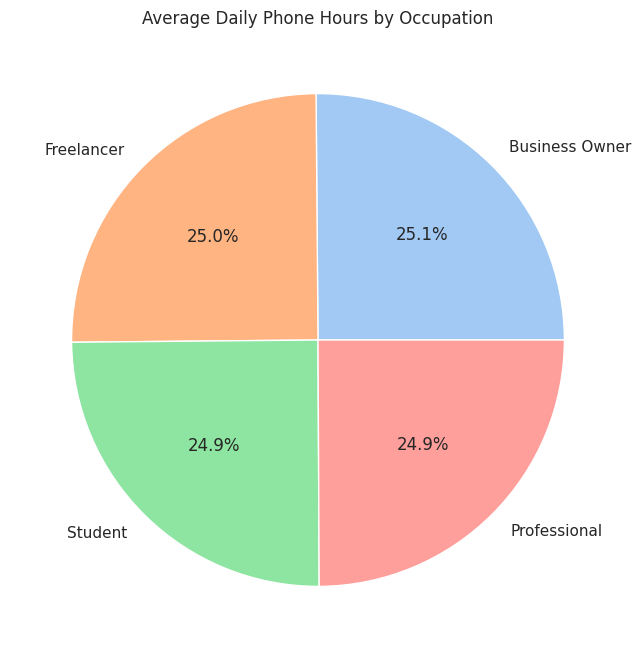

In [25]:
plt.figure(figsize=(8, 8))
plt.pie(occ_usage.values, labels=occ_usage.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Average Daily Phone Hours by Occupation')
plt.savefig('viz1_occupation_usage.png')
plt.show()

# --- B. BAR CHART - DEVICE TYPE DISTRIBUTION ---

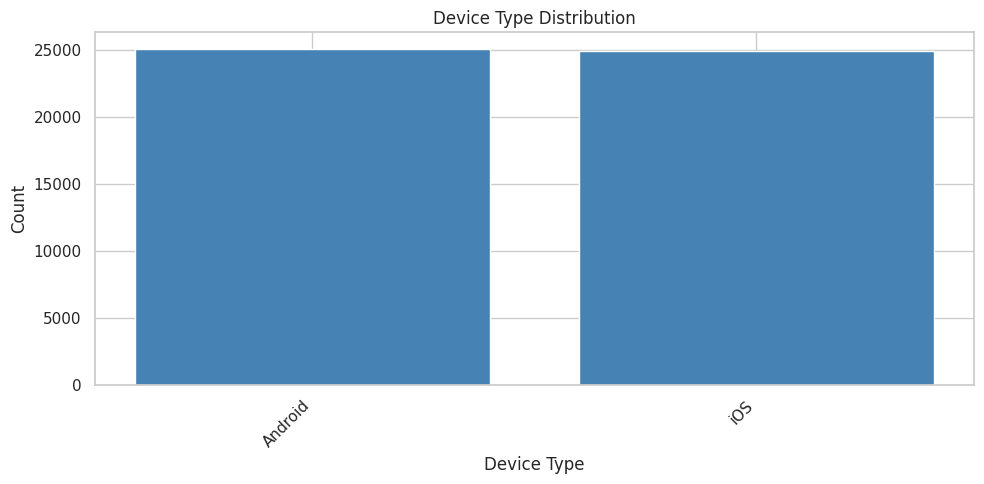

In [26]:
device_counts = df['Device_Type'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(device_counts.index, device_counts.values, color='steelblue')
plt.title('Device Type Distribution')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('viz2_device_distribution.png')
plt.show()

# --- C. LINE CHART - AGE vs AVERAGE PHONE HOURS ---

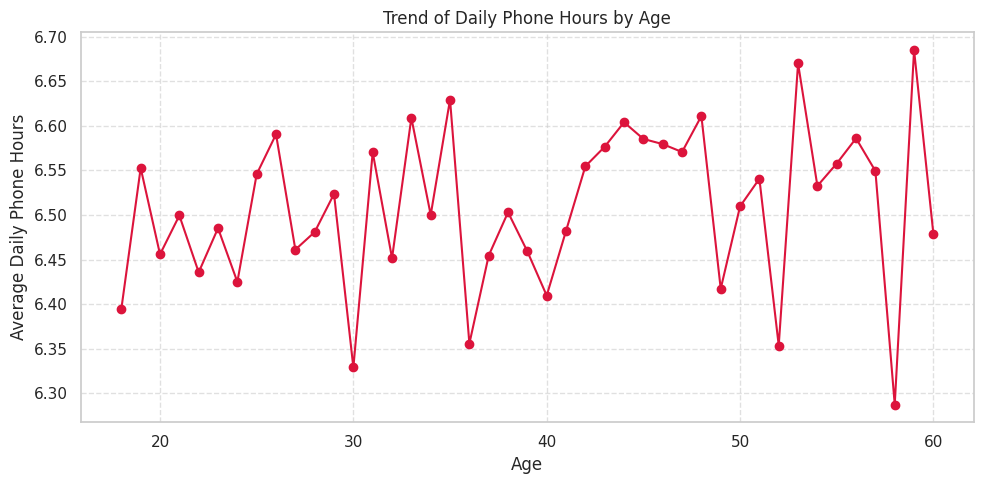

In [27]:
age_usage = df.groupby('Age')['Daily_Phone_Hours'].mean().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(age_usage['Age'], age_usage['Daily_Phone_Hours'], marker='o', color='crimson')
plt.title('Trend of Daily Phone Hours by Age')
plt.xlabel('Age')
plt.ylabel('Average Daily Phone Hours')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('viz3_age_trend.png')
plt.show()

# --- D. HEATMAP - CORRELATION MATRIX ---

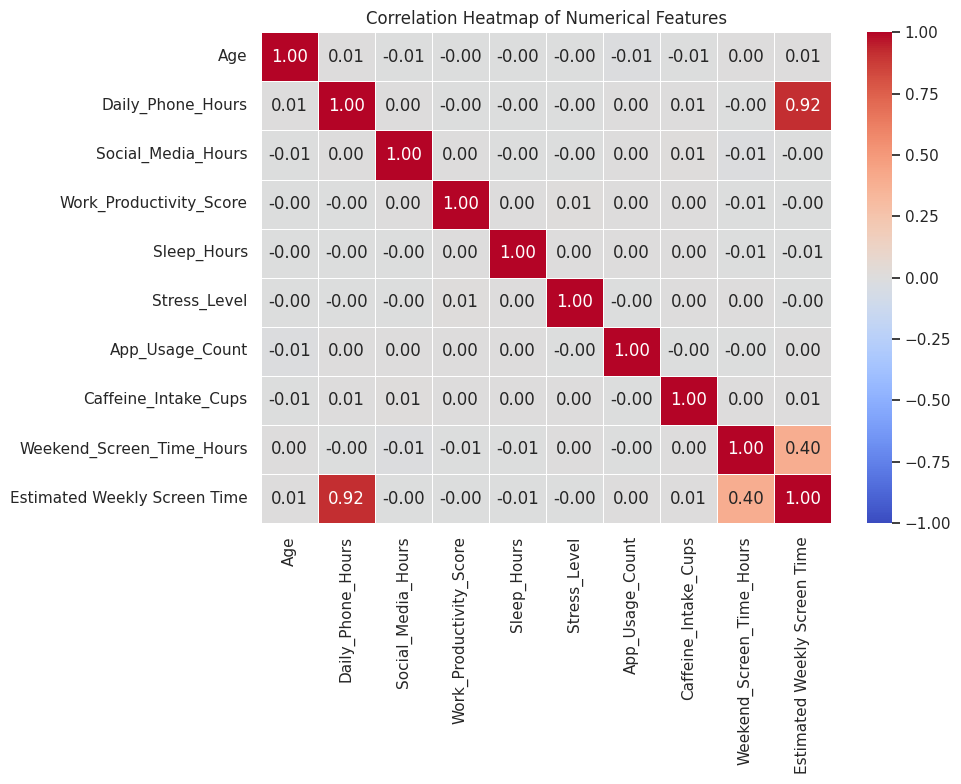

In [28]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png')
plt.show()